# 01 · Implied vs realized volatility

Part 1 of 5. This notebook answers the first question of the project: **how large is the gap between the VIX and the volatility the S&P 500 actually goes on to deliver, and how stable is it?**

The VIX is the market's price for the next 30 days of S&P 500 volatility, quoted in annualized percentage points. The realized volatility it is compared with is measured *afterwards*: for each day, the annualized volatility of the daily log returns over the following 21 trading days.

```
RV(t, t+21) = 252 / 21 * sum_{i=1..21} r(t+i)^2
```

If option buyers pay more than they later receive, the difference is the volatility risk premium, and it is what an option seller is paid for carrying the risk.

The analysis window is January 2020 to September 2026. Data before 2020 is loaded only because the forecasting models of notebook 02 need a training history.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vrp.data import load_market_data
from vrp.volatility import forward_realized_variance, log_returns

END = "2026-09-25"                   # last complete session used for the published results
EVAL_START = pd.Timestamp("2020-01-01")

data = load_market_data("yahoo", "1990-01-01", END)
spx, vix = data["spx"], data["vix"]
returns = log_returns(spx)
realized_var = forward_realized_variance(returns)   # RV(t, t+21), annualised
realized_vol = np.sqrt(realized_var)
implied_var = (vix / 100) ** 2
print(f"{len(data):,} daily observations, {spx.index[0].date()} to {spx.index[-1].date()}")

9,251 daily observations, 1990-01-02 to 2026-09-25


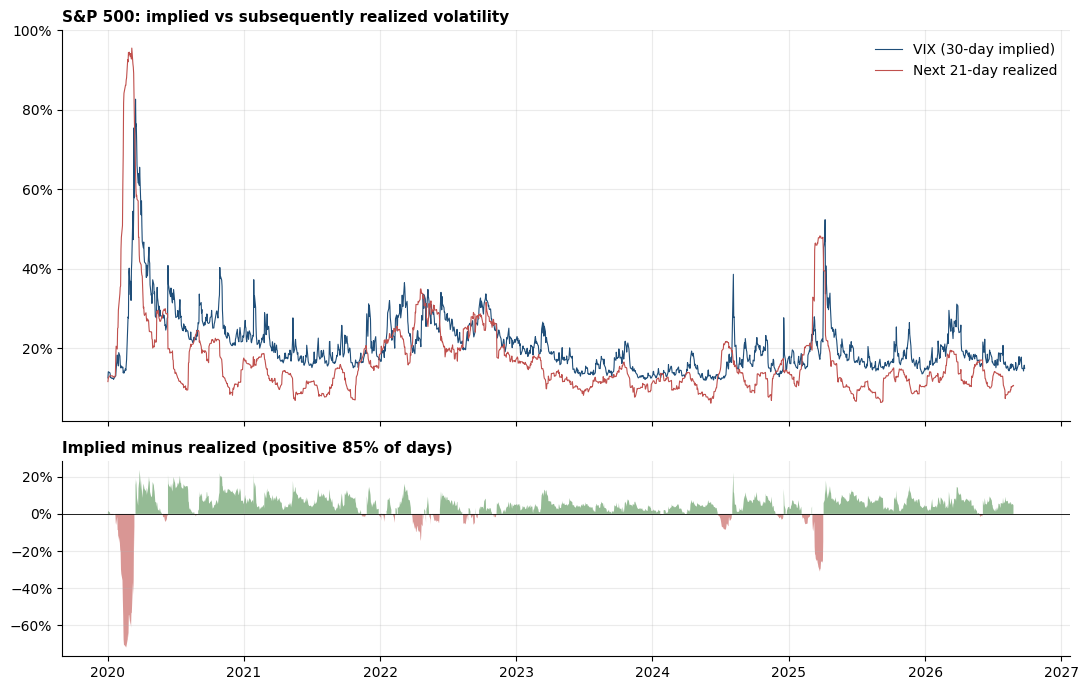

In [2]:
from vrp.plots import plot_implied_vs_realized

window = slice(EVAL_START, None)
plot_implied_vs_realized(vix.loc[window], realized_vol.loc[window])

The top panel shows the VIX (blue) and the volatility that followed (red). The bottom panel is their difference: green when the VIX was higher than what materialized, red when it was lower. Note that the last 21 days of the sample have no realized value yet, so the red line stops one month before the blue one.

In [3]:
from vrp.pipeline import volatility_premium

stats = volatility_premium(vix.loc[window], realized_var.loc[window])
stats.rename({
    "mean_implied_vol": "average VIX",
    "mean_realized_vol": "average realized vol (next 21 days)",
    "mean_spread_vol_pts": "average gap (vol points)",
    "share_positive": "share of days with VIX above realized",
    "worst_spread_vol_pts": "worst gap (vol points)",
}).round(3).to_frame("value")

,value
average VIX,0.208
average realized vol (next 21 days),0.169
average gap (vol points),3.828
share of days with VIX above realized,0.849
worst gap (vol points),-71.963


## The premium year by year

In [4]:
spread = (vix / 100 - realized_vol).dropna().loc[window]
year = spread.index.year

by_year = pd.DataFrame({
    "average VIX": vix.loc[spread.index].groupby(year).mean(),
    "average realized vol": (100 * realized_vol.loc[spread.index]).groupby(year).mean(),
    "gap (vol points)": (100 * spread).groupby(year).mean(),
    "share of days VIX above": (spread > 0).groupby(year).mean(),
    "worst gap (vol points)": (100 * spread).groupby(year).min(),
})
by_year.index.name = "year"
by_year.round(2)

,average VIX,average realized vol,gap (vol points),share of days VIX above,worst gap (vol points)
year,,,,,
2020,29.25,27.09,2.16,0.77,-71.96
2021,19.66,12.79,6.87,0.95,-2.05
2022,25.62,23.74,1.89,0.65,-14.58
2023,16.87,12.55,4.32,1.00,0.11
2024,15.61,12.43,3.18,0.81,-8.46
2025,18.96,15.44,3.52,0.84,-31.10
2026,18.66,13.23,5.43,0.96,-1.64


The premium is positive on average in every year, but its size varies a lot. It is largest in 2021 (6.9 points) and smallest in the two years dominated by a shock, 2020 (2.2) and 2022 (1.9). In 2022 the VIX was above what followed on only 65% of days, against 95% or more in 2021, 2023 and 2026. A year can look profitable on average and still contain the days that matter.

## What the distribution looks like

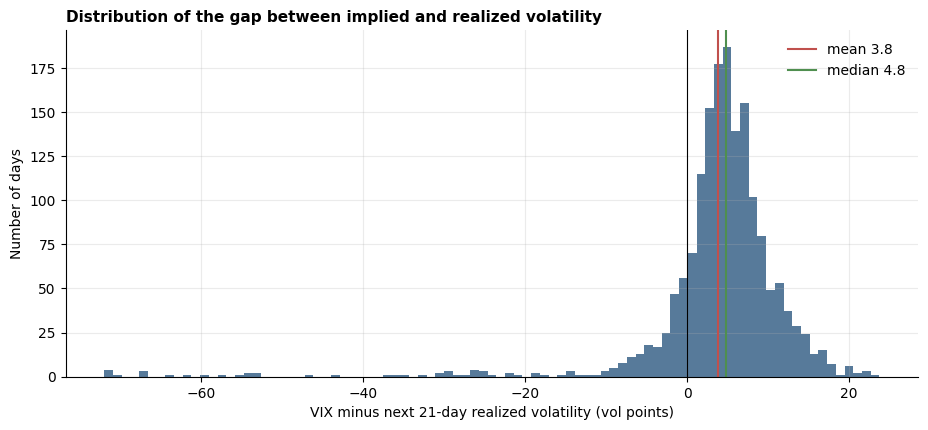

In [5]:
from vrp.plots import PALETTE, style

gap = 100 * spread
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(gap, bins=np.linspace(gap.min(), gap.max(), 90), color=PALETTE[0], alpha=0.75)
ax.axvline(gap.mean(), color=PALETTE[1], lw=1.5, label=f"mean {gap.mean():.1f}")
ax.axvline(gap.median(), color=PALETTE[2], lw=1.5, label=f"median {gap.median():.1f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("VIX minus next 21-day realized volatility (vol points)")
ax.set_ylabel("Number of days")
ax.legend(frameon=False)
style(ax, "Distribution of the gap between implied and realized volatility")
plt.close(fig)
fig

About 71% of days sit between zero and ten points, so the median gap (4.8) is above the mean (3.8). The mean is pulled down by the left tail: 52 days are more than 10 points below zero, and 25 of them are more than 30 points below, nearly all in February-March 2020 and April 2025. That is the shape of the trade that follows. A seller collects a small, frequent premium and occasionally gives a lot of it back.

## Does the gap persist?

In [6]:
persistence = pd.Series({f"{lag} trading days": spread.autocorr(lag) for lag in (1, 5, 21, 63)}, name="autocorrelation of the gap")
persistence.round(2).to_frame()

,autocorrelation of the gap
1 trading days,0.96
5 trading days,0.80
21 trading days,0.08
63 trading days,0.12


The autocorrelation at one day is high mostly because consecutive 21-day windows overlap. The number to read is the one at 21 days, where windows no longer overlap: it is close to zero. Knowing that the gap is large today says almost nothing about the gap a month from now, so the premium cannot be timed from its current size alone. That is the question notebook 02 tries to answer with better forecasts.

In [7]:
display(Markdown(
    f"**Summary.** Over {len(spread):,} days the VIX averaged {vix.loc[spread.index].mean():.1f} against "
    f"{100 * realized_vol.loc[spread.index].mean():.1f} realized, a gap of {gap.mean():.1f} vol points. "
    f"The VIX was higher than what followed on {100 * (spread > 0).mean():.0f}% of days, "
    f"and lower on the other {100 * (spread <= 0).mean():.0f}%, with a worst case of {gap.min():.0f} points "
    f"on {gap.idxmin().date()}."
))

**Summary.** Over 1,671 days the VIX averaged 20.8 against 16.9 realized, a gap of 3.8 vol points. The VIX was higher than what followed on 85% of days, and lower on the other 15%, with a worst case of -72 points on 2020-02-20.